In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.model_selection import cross_val_score

In [2]:
df = pd.read_csv("medical_insurance.csv")
df.head()

,record_date,year,quarter,age,age_group,sex,sex_female,bmi,bmi_category,children,...,region,region_northeast,region_northwest,region_southeast,region_southwest,charges,monthly_premium_est,charges_per_child,insurance_tier,bmi_age_interaction
0,2024-02-01,2024,1,19,Young Adult (18-25),female,1,27.90,Overweight,0,...,southwest,0,0,0,1,16884.92,1407.08,0.00,Platinum,530.10
1,2024-12-30,2024,4,18,Young Adult (18-25),male,0,33.77,Obese Class I,1,...,southeast,0,0,1,0,1725.55,143.80,1725.55,Bronze,607.86
2,2023-05-11,2023,2,28,Adult (26-35),male,0,33.00,Obese Class I,3,...,southeast,0,0,1,0,4449.46,370.79,1483.15,Silver,924.00
3,2024-07-18,2024,3,33,Adult (26-35),male,0,22.70,Normal Weight,0,...,northwest,0,1,0,0,21984.47,1832.04,0.00,Diamond,749.10
4,2024-02-05,2024,1,32,Adult (26-35),male,0,28.88,Overweight,0,...,northwest,0,1,0,0,3866.86,322.24,0.00,Bronze,924.16


In [3]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1337 entries, 0 to 1336
Data columns (total 24 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   record_date          1337 non-null   object 
 1   year                 1337 non-null   int64  
 2   quarter              1337 non-null   int64  
 3   age                  1337 non-null   int64  
 4   age_group            1337 non-null   object 
 5   sex                  1337 non-null   object 
 6   sex_female           1337 non-null   int64  
 7   bmi                  1337 non-null   float64
 8   bmi_category         1337 non-null   object 
 9   children             1337 non-null   int64  
 10  smoker               1337 non-null   object 
 11  smoker_flag          1337 non-null   int64  
 12  is_high_risk         1337 non-null   int64  
 13  risk_score           1337 non-null   float64
 14  region               1337 non-null   object 
 15  region_northeast     1337 non-null   i

,year,quarter,age,sex_female,bmi,children,smoker_flag,is_high_risk,risk_score,region_northeast,region_northwest,region_southeast,region_southwest,charges,monthly_premium_est,charges_per_child,bmi_age_interaction
count,1337.000000,1337.000000,1337.000000,1337.000000,1337.000000,1337.000000,1337.000000,1337.000000,1337.000000,1337.000000,1337.000000,1337.000000,1337.000000,1337.000000,1337.000000,1337.000000,1337.000000
mean,2023.036649,2.477936,39.222139,0.495138,30.663628,1.095737,0.204936,0.624533,3.052939,0.242334,0.242334,0.272251,0.243082,13279.121503,1106.593328,5127.538257,1212.054233
std,1.384042,1.121910,14.044333,0.500163,6.100233,1.205571,0.403806,0.484425,1.981412,0.428655,0.428655,0.445285,0.429104,12110.359677,1009.196560,8357.618626,522.515951
min,2021.000000,1.000000,18.000000,0.000000,15.960000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1121.870000,93.490000,0.000000,287.280000
25%,2022.000000,1.000000,27.000000,0.000000,26.290000,0.000000,0.000000,0.000000,1.690000,0.000000,0.000000,0.000000,0.000000,4746.340000,395.530000,0.000000,765.700000
50%,2023.000000,2.000000,39.000000,0.000000,30.400000,1.000000,0.000000,1.000000,2.480000,0.000000,0.000000,0.000000,0.000000,9386.160000,782.180000,2174.730000,1154.400000
75%,2024.000000,4.000000,51.000000,1.000000,34.700000,2.000000,0.000000,1.000000,3.410000,0.000000,0.000000,1.000000,0.000000,16657.720000,1388.140000,6399.980000,1589.280000
max,2025.000000,4.000000,64.000000,1.000000,53.130000,5.000000,1.000000,1.000000,8.320000,1.000000,1.000000,1.000000,1.000000,63770.430000,5314.200000,58571.070000,2845.480000


In [4]:
df.isnull().sum()

record_date            0
year                   0
quarter                0
age                    0
age_group              0
sex                    0
sex_female             0
bmi                    0
bmi_category           0
children               0
smoker                 0
smoker_flag            0
is_high_risk           0
risk_score             0
region                 0
region_northeast       0
region_northwest       0
region_southeast       0
region_southwest       0
charges                0
monthly_premium_est    0
charges_per_child      0
insurance_tier         0
bmi_age_interaction    0
dtype: int64

In [5]:
df['record_date'] = pd.to_datetime(df['record_date'])

In [6]:
df['children'].unique()

array([0, 1, 3, 2, 5, 4])

In [7]:
df['sex'].unique()

array(['female', 'male'], dtype=object)

In [8]:
df['smoker'].unique()

array(['yes', 'no'], dtype=object)

In [9]:
df['region'].unique()

array(['southwest', 'southeast', 'northwest', 'northeast'], dtype=object)

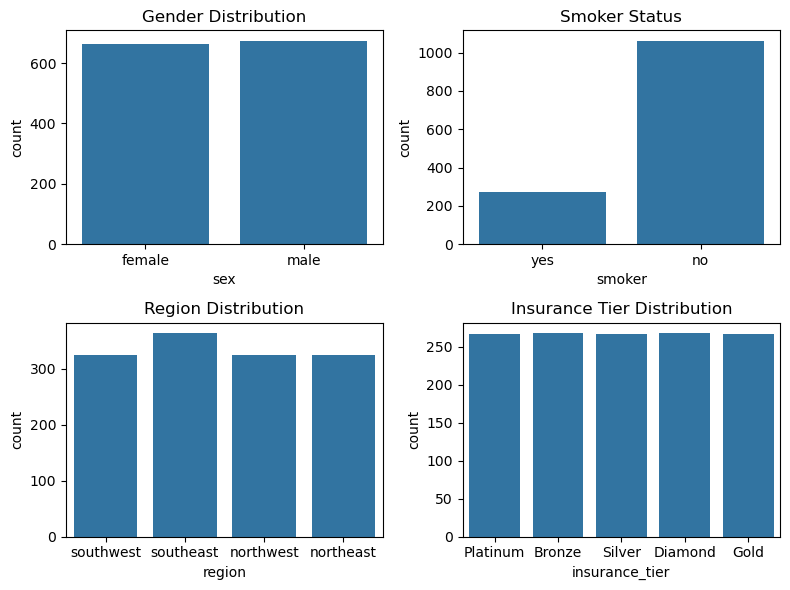

In [10]:
fig, axes = plt.subplots(2, 2, figsize=(8, 6))

sns.countplot(x='sex', data=df, ax=axes[0,0])
axes[0,0].set_title("Gender Distribution")

sns.countplot(x='smoker', data=df, ax=axes[0,1])
axes[0,1].set_title("Smoker Status")

sns.countplot(x='region', data=df, ax=axes[1,0])
axes[1,0].set_title("Region Distribution")

sns.countplot(x='insurance_tier', data=df, ax=axes[1,1])
axes[1,1].set_title("Insurance Tier Distribution")

plt.tight_layout()
plt.show()

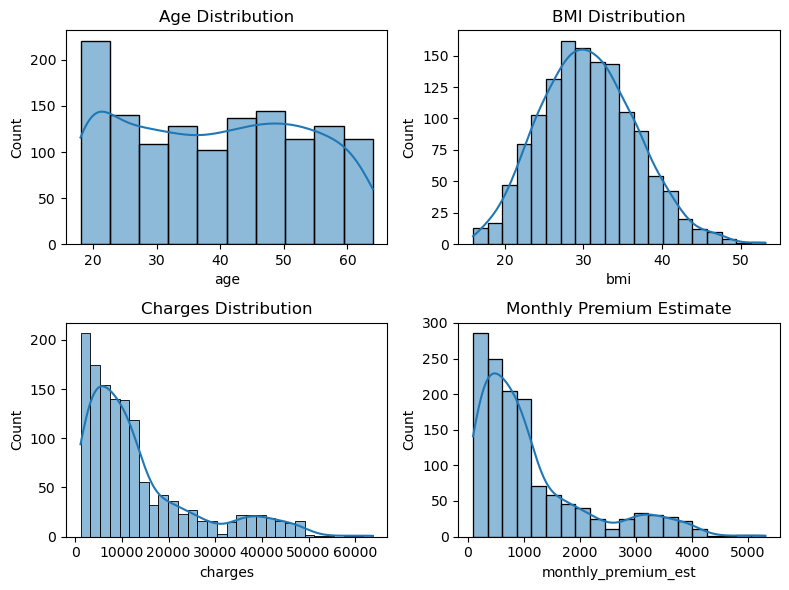

In [11]:
fig, axes = plt.subplots(2, 2, figsize=(8, 6))

sns.histplot(df['age'], bins=10, kde=True, ax=axes[0,0])
axes[0,0].set_title("Age Distribution")

sns.histplot(df['bmi'], bins=20, kde=True, ax=axes[0,1])
axes[0,1].set_title("BMI Distribution")

sns.histplot(df['charges'], bins=30, kde=True, ax=axes[1,0])
axes[1,0].set_title("Charges Distribution")

sns.histplot(df['monthly_premium_est'], bins=20, kde=True, ax=axes[1,1])
axes[1,1].set_title("Monthly Premium Estimate")

plt.tight_layout()
plt.show()

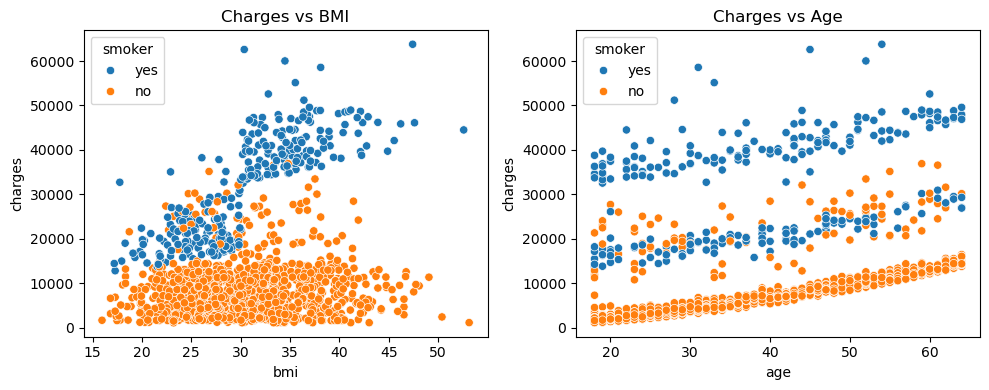

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

sns.scatterplot(x='bmi', y='charges', hue='smoker', data=df, ax=axes[0])
axes[0].set_title("Charges vs BMI")

sns.scatterplot(x='age', y='charges', hue='smoker', data=df, ax=axes[1])
axes[1].set_title("Charges vs Age")
plt.tight_layout()
plt.show()

In [13]:
numeric_features = ['age', 'bmi', 'children']
categorical_features = ['sex', 'smoker', 'region']

In [14]:
X = df[numeric_features + categorical_features]
y_risk = df['is_high_risk']

In [15]:
X_train, X_test, y_train_risk, y_test_risk = train_test_split(
    X, y_risk, test_size=0.2, random_state=42)

In [16]:
numeric_transformer = StandardScaler()
categorical_transformer = OneHotEncoder(handle_unknown='ignore')

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)])

In [17]:
risk_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', RandomForestClassifier())])

In [18]:
risk_pipeline.fit(X_train, y_train_risk)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['age', 'bmi', 'children']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['sex', 'smoker',
                                                   'region'])])),
                ('model', RandomForestClassifier())])

In [19]:
risk_pred = risk_pipeline.predict(X_test)

In [20]:
print("Risk Accuracy:", accuracy_score(y_test_risk, risk_pred))

Risk Accuracy: 1.0


In [21]:
print("Accuracy:", accuracy_score(y_test_risk, risk_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test_risk, risk_pred))
print("Classification Report:\n", classification_report(y_test_risk, risk_pred))

Accuracy: 1.0
Confusion Matrix:
 [[ 93   0]
 [  0 175]]
Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        93
           1       1.00      1.00      1.00       175

    accuracy                           1.00       268
   macro avg       1.00      1.00      1.00       268
weighted avg       1.00      1.00      1.00       268



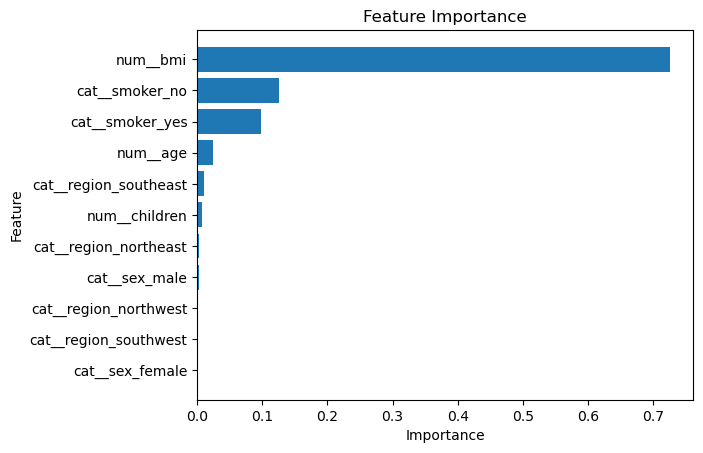

In [22]:
feature_names = risk_pipeline.named_steps['preprocessor'].get_feature_names_out()
importances = risk_pipeline.named_steps['model'].feature_importances_

feat_imp = pd.DataFrame({'feature': feature_names,
    'importance': importances}).sort_values(by='importance', ascending=False)

# Plot
plt.figure()
plt.barh(feat_imp['feature'], feat_imp['importance'])
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Feature Importance")
plt.gca().invert_yaxis()
plt.show()

In [23]:
import joblib
# Save model
joblib.dump(risk_pipeline, "best_model.pkl")

['best_model.pkl']

In [24]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1337 entries, 0 to 1336
Data columns (total 24 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   record_date          1337 non-null   datetime64[ns]
 1   year                 1337 non-null   int64         
 2   quarter              1337 non-null   int64         
 3   age                  1337 non-null   int64         
 4   age_group            1337 non-null   object        
 5   sex                  1337 non-null   object        
 6   sex_female           1337 non-null   int64         
 7   bmi                  1337 non-null   float64       
 8   bmi_category         1337 non-null   object        
 9   children             1337 non-null   int64         
 10  smoker               1337 non-null   object        
 11  smoker_flag          1337 non-null   int64         
 12  is_high_risk         1337 non-null   int64         
 13  risk_score           1337 non-nul

In [25]:
X = df[numeric_features + categorical_features]
y_charges = df['charges']  

In [26]:
X_train, X_test, y_train_charges, y_test_charges = train_test_split(
    X, y_charges, test_size=0.2, random_state=42)

In [33]:
charges_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model2', RandomForestRegressor())])

In [34]:
charges_pipeline.fit(X_train, y_train_charges)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['age', 'bmi', 'children']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['sex', 'smoker',
                                                   'region'])])),
                ('model2', RandomForestRegressor())])

In [35]:
charges_pred = charges_pipeline.predict(X_test)

In [36]:
print("RMSE:", np.sqrt(mean_squared_error(y_test_charges, charges_pred)))

RMSE: 4653.391590986599


In [37]:
print('Mean_absolute_error',mean_absolute_error(y_test_charges,charges_pred))
print('Mean_squared_error',mean_squared_error(y_test_charges,charges_pred))
print('Root_mean_squared_error',np.sqrt(mean_squared_error(y_test_charges,charges_pred)))
print("R2 Score",r2_score(y_test_charges,charges_pred))

Mean_absolute_error 2585.3343507462682
Mean_squared_error 21654053.299064793
Root_mean_squared_error 4653.391590986599
R2 Score 0.8821587024123709


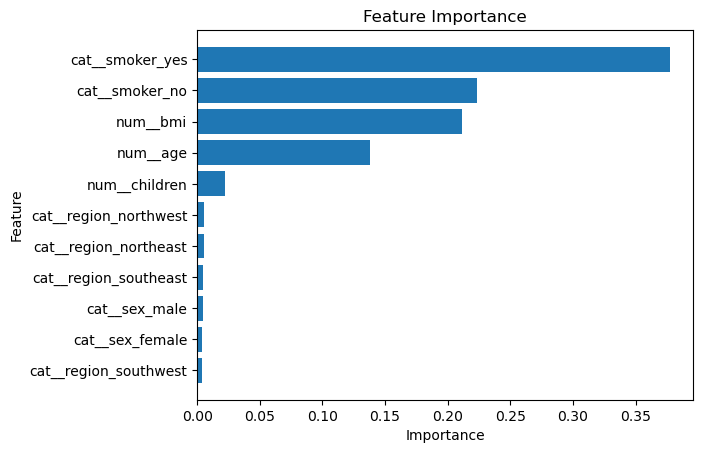

In [39]:
feature_names = charges_pipeline.named_steps['preprocessor'].get_feature_names_out()
importances = charges_pipeline.named_steps['model2'].feature_importances_

feat_imp = pd.DataFrame({'feature': feature_names,
    'importance': importances}).sort_values(by='importance', ascending=False)

# Plot
plt.figure()
plt.barh(feat_imp['feature'], feat_imp['importance'])
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Feature Importance")
plt.gca().invert_yaxis()
plt.show()

In [38]:
import joblib
# Save  pipeline (preprocessing + classifier)
joblib.dump(charges_pipeline, "best_model2.pkl")

['best_model2.pkl']